# 11. Calibración de Umbrales y Explicabilidad Avanzada con SHAP

Este notebook corresponde a la **Fase 3: Tarea 3.5 - Calibración de Umbrales y Explicabilidad Avanzada con SHAP**.
El objetivo de esta etapa es:
1. **Calibrar dinámicamente el umbral de decisión** de nuestro modelo LightGBM optimizado para priorizar la protección civil, evaluando cómo al reducir el umbral de decisión rígido de 0.50 a valores más conservadores (como 0.30) maximizamos la detección de incendios reales (Recall) y monitorizamos el $F_2$-Score (donde el Recall pesa el doble que la precisión).
2. **Generar explicabilidad global mediante SHAP**, utilizando el `TreeExplainer` de LightGBM para obtener el gráfico Beeswarm y el gráfico de barras de importancia de variables, revelando los inductores físicos principales de los incendios en la Comunidad Valenciana.
3. **Desarrollar explicabilidad local e informes en texto plano** para justificar de forma automatizada y amigable las causas y empujes individuales de riesgo para cualquier ignición o punto del territorio.

## 1. Carga de Librerías y Matrices Preprocesadas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from lightgbm import LGBMClassifier
import shap


from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    fbeta_score
)


BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "datos" / "processed"
FIG_DIR = BASE_DIR / "entregas" / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)


X_TRAIN_PATH = DATA_DIR / "X_train.csv"
X_TEST_PATH = DATA_DIR / "X_test.csv"
Y_TRAIN_PATH = DATA_DIR / "y_train.csv"
Y_TEST_PATH = DATA_DIR / "y_test.csv"

print("Cargando matrices preprocesadas...")
X_train = pd.read_csv(X_TRAIN_PATH, sep=';', decimal=',')
X_test = pd.read_csv(X_TEST_PATH, sep=';', decimal=',')
y_train = pd.read_csv(Y_TRAIN_PATH, sep=';', decimal=',')['target']
y_test = pd.read_csv(Y_TEST_PATH, sep=';', decimal=',')['target']

print(f"\nDimensiones cargadas exitosamente:")
print(f"- X_train: {X_train.shape[0]} filas x {X_train.shape[1]} columnas")
print(f"- y_train: {y_train.shape[0]} registros")
print(f"- X_test : {X_test.shape[0]} filas x {X_test.shape[1]} columnas")
print(f"- y_test : {y_test.shape[0]} registros")

Cargando matrices preprocesadas...

Dimensiones cargadas exitosamente:
- X_train: 7161 filas x 23 columnas
- y_train: 7161 registros
- X_test : 1791 filas x 23 columnas
- y_test : 1791 registros


## 2. Adecuación de Tipos de Datos y Entrenamiento del Modelo Optimizado

Entrenamos nuestro estimador final campeón de LightGBM utilizando los hiperparámetros "humanizados" y redondeados resultantes de nuestra optimización avanzada.

In [2]:

cols_bool = [col for col in X_train.columns if X_train[col].dtype == 'bool']
for col in cols_bool:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)


best_params = {
    'n_estimators': 134,
    'learning_rate': 0.056,
    'max_depth': 9,
    'num_leaves': 100,
    'min_child_samples': 17,
    'subsample': 0.70,
    'colsample_bytree': 0.69,
    'random_state': 42,
    'verbose': -1
}


best_lgbm = LGBMClassifier(**best_params)
print("Entrenando modelo campeón de LightGBM...")
best_lgbm.fit(X_train, y_train)
print("¡Entrenamiento finalizado exitosamente!")


y_proba = best_lgbm.predict_proba(X_test)[:, 1]

Entrenando modelo campeón de LightGBM...
¡Entrenamiento finalizado exitosamente!


## 3. Calibración de Umbrales de Decisión (El Efecto Tutor)

En protección civil, los Falsos Negativos (incendios no detectados) son infinitamente más costosos que las Falsas Alarmas (Falsos Positivos). Evaluaremos el impacto de variar el umbral de decisión rígido de `0.50` a valores más conservadores (`0.40`, `0.30`, `0.20`) calculando la matriz de confusión y el **$F_2$-Score** (que otorga el doble de relevancia al Recall sobre la Precisión).

       BARRIDO DE UMBRALES DE DECISIÓN (PROTECCIÓN CIVIL)
Umbral 0.50 -> F2-Score: 0.83105 | Recall: 81.45% | Precision: 90.45%
   [Falsos Negativos (Fuegos Omitidos)]: 166 | [Falsos Positivos (Alarmas Falsas)]: 77
------------------------------------------------------------------
Umbral 0.40 -> F2-Score: 0.86358 | Recall: 86.15% | Precision: 87.22%
   [Falsos Negativos (Fuegos Omitidos)]: 124 | [Falsos Positivos (Alarmas Falsas)]: 113
------------------------------------------------------------------
Umbral 0.30 -> F2-Score: 0.87842 | Recall: 89.61% | Precision: 81.42%
   [Falsos Negativos (Fuegos Omitidos)]: 93 | [Falsos Positivos (Alarmas Falsas)]: 183
------------------------------------------------------------------
Umbral 0.20 -> F2-Score: 0.88418 | Recall: 92.29% | Precision: 75.71%
   [Falsos Negativos (Fuegos Omitidos)]: 69 | [Falsos Positivos (Alarmas Falsas)]: 265
------------------------------------------------------------------

Panel comparativo de matrices de confusión g

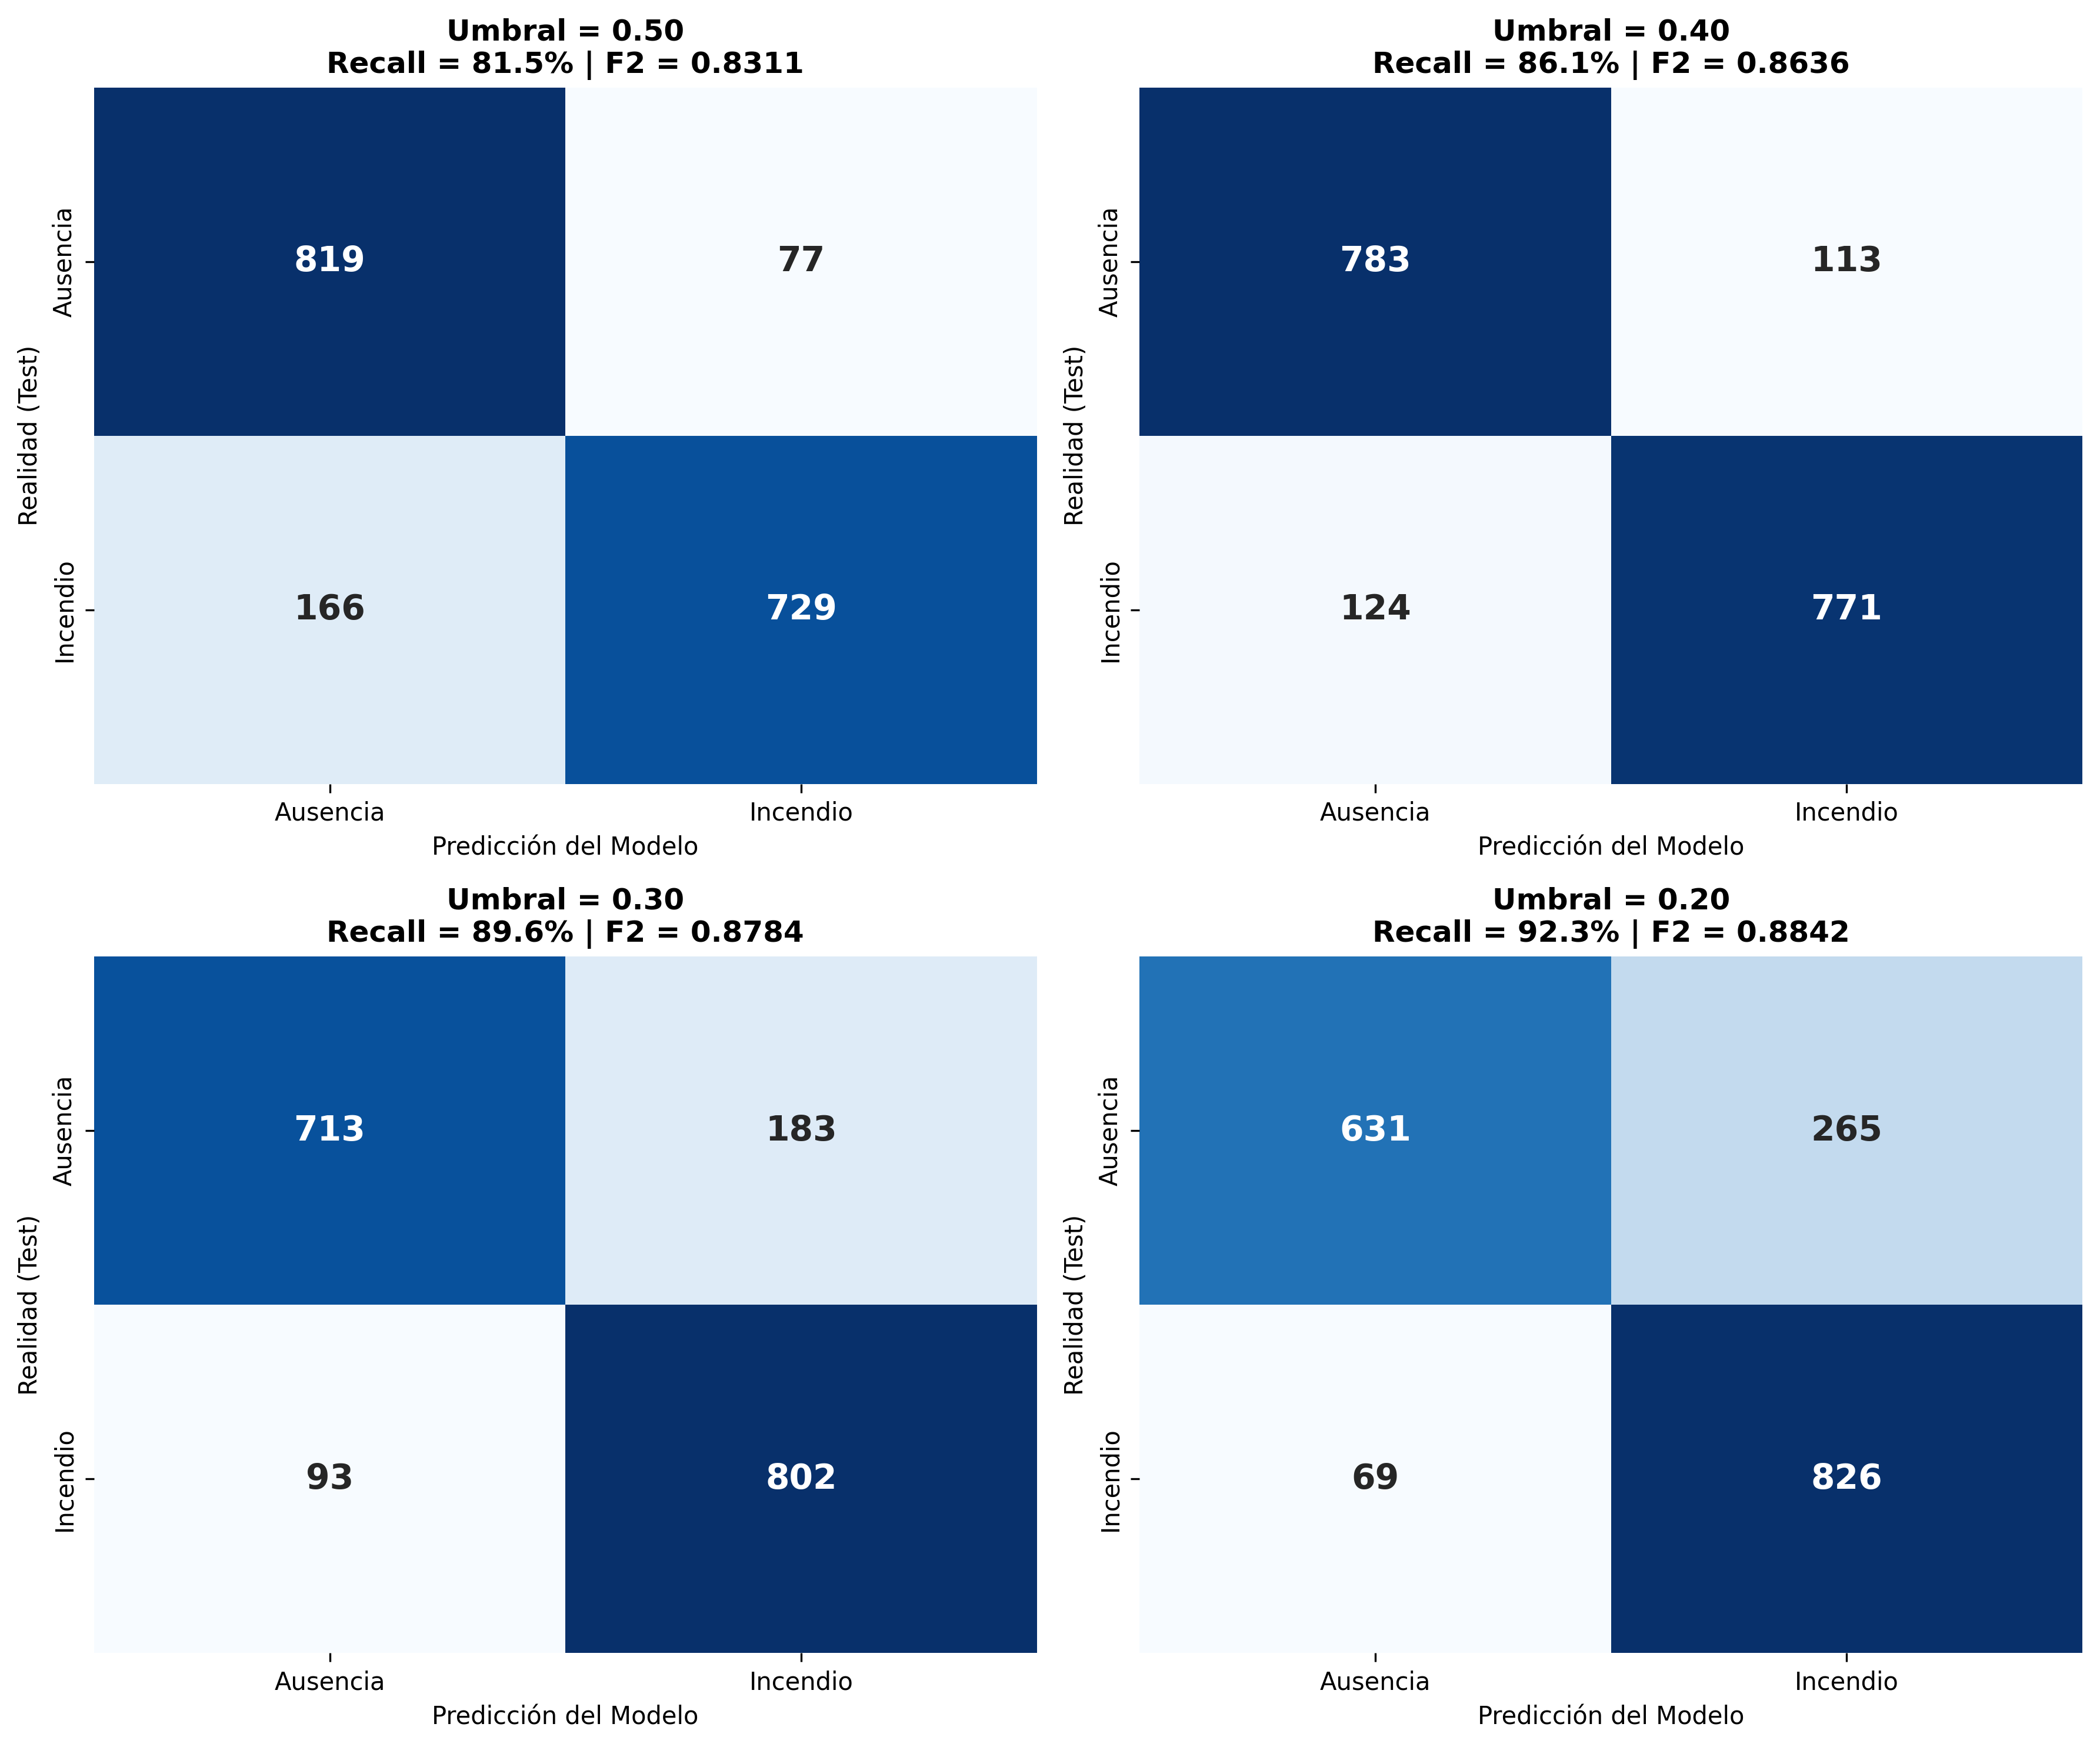

In [3]:

umbrales = [0.50, 0.40, 0.30, 0.20]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
axes = axes.ravel()

print("==================================================================")
print("       BARRIDO DE UMBRALES DE DECISIÓN (PROTECCIÓN CIVIL)")
print("==================================================================")

for idx, threshold in enumerate(umbrales):
    
    y_pred_thresh = (y_proba >= threshold).astype(int)
    
    
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f2 = fbeta_score(y_test, y_pred_thresh, beta=2)
    
    print(f"Umbral {threshold:.2f} -> F2-Score: {f2:.5f} | Recall: {recall*100:.2f}% | Precision: {precision*100:.2f}%")
    print(f"   [Falsos Negativos (Fuegos Omitidos)]: {fn} | [Falsos Positivos (Alarmas Falsas)]: {fp}")
    print("------------------------------------------------------------------")
    
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'},
                xticklabels=['Ausencia', 'Incendio'], yticklabels=['Ausencia', 'Incendio'])
    axes[idx].set_title(f"Umbral = {threshold:.2f}\nRecall = {recall*100:.1f}% | F2 = {f2:.4f}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicción del Modelo', fontsize=10)
    axes[idx].set_ylabel('Realidad (Test)', fontsize=10)

plt.tight_layout()
FIG_CALIB_PATH = FIG_DIR / "13a_Calibracion_Matrices_Confusion.png"
plt.savefig(FIG_CALIB_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPanel comparativo de matrices de confusión guardado exitosamente en: {FIG_CALIB_PATH.name}")

## 4. Explicabilidad Global del Modelo: SHAP Global

Utilizaremos `shap.TreeExplainer` para desentrañar la lógica global del modelo y revelar la importancia de las características de forma matemática y visual. Pintaremos y guardaremos en un único gráfico premium combinado en alta resolución (300 DPI) la importancia media y la distribución de contribuciones (Beeswarm).

Calculando valores SHAP para el bloque de Test...
¡Valores SHAP calculados con éxito!
Gráfica premium combinada de SHAP Global guardada en: 13_Explicabilidad_Global_SHAP.png


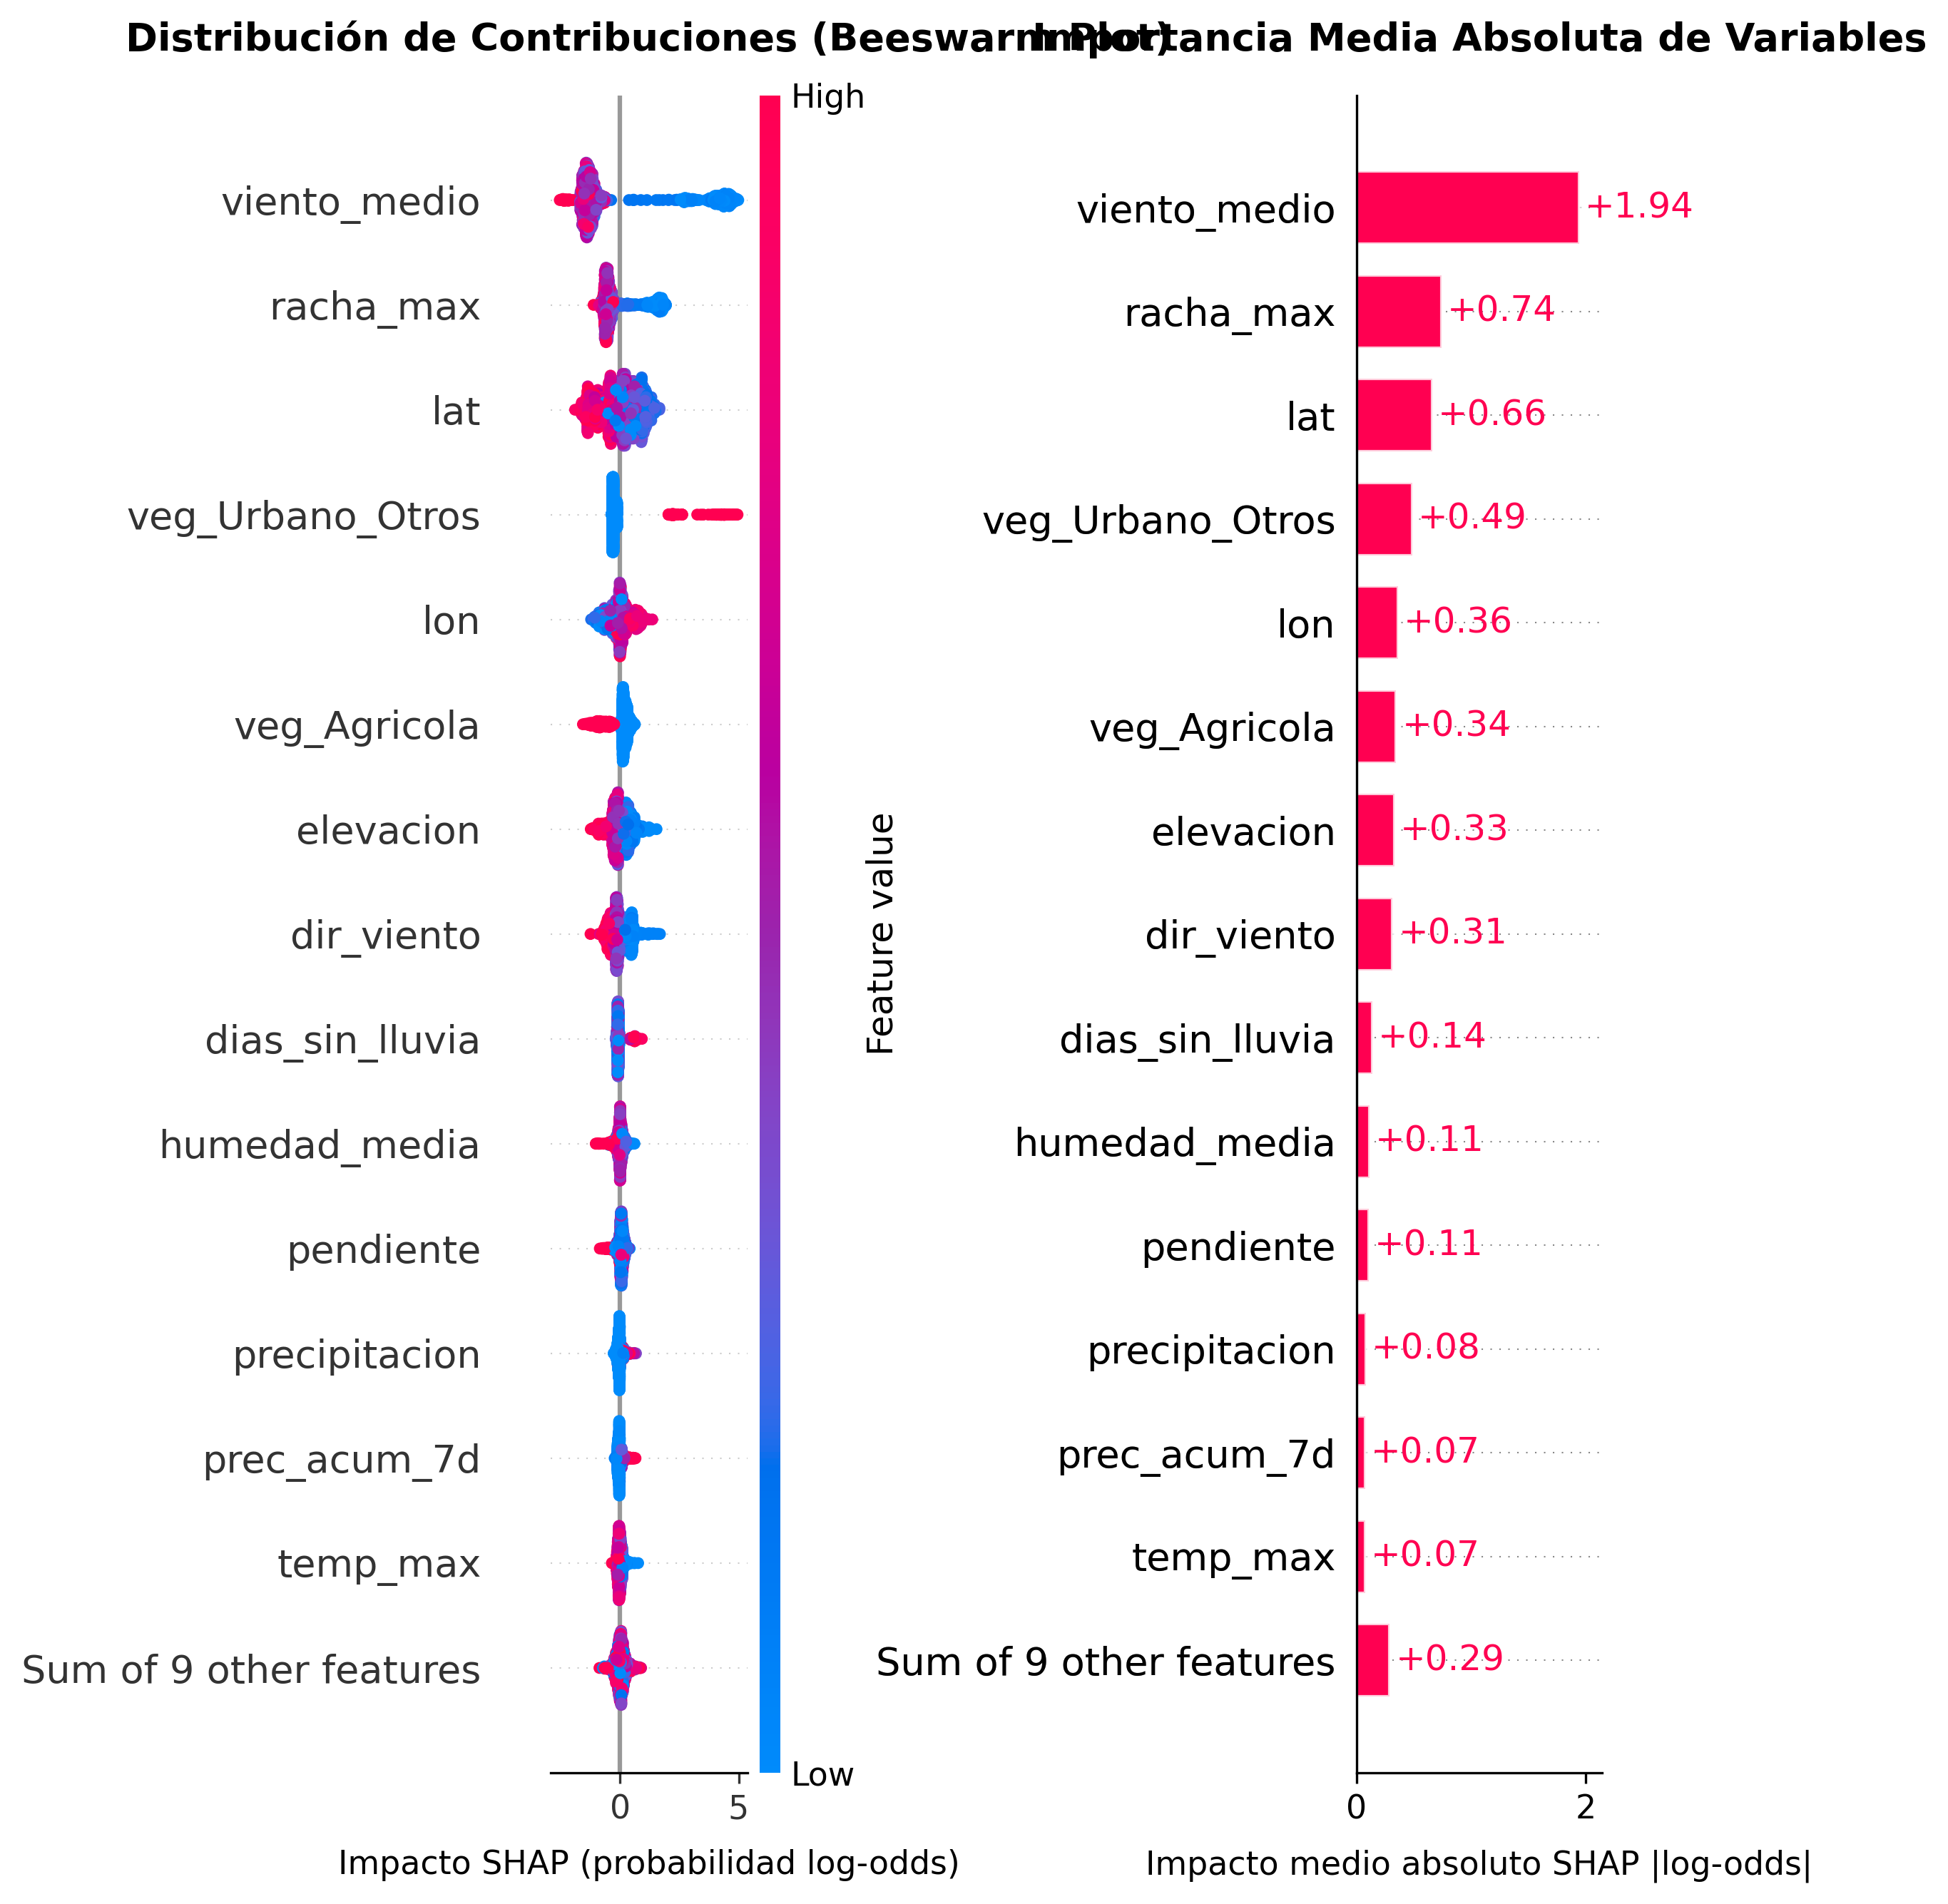

In [4]:

explainer = shap.TreeExplainer(best_lgbm)
print("Calculando valores SHAP para el bloque de Test...")
shap_values = explainer(X_test)
print("¡Valores SHAP calculados con éxito!")


fig = plt.figure(figsize=(18, 8), dpi=300)


plt.subplot(1, 2, 1)
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("Distribución de Contribuciones (Beeswarm Plot)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Impacto SHAP (probabilidad log-odds)", fontsize=11, labelpad=8)


plt.subplot(1, 2, 2)
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Importancia Media Absoluta de Variables", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Impacto medio absoluto SHAP |log-odds|", fontsize=11, labelpad=8)


plt.tight_layout()
SHAP_FIG_PATH = FIG_DIR / "13_Explicabilidad_Global_SHAP.png"
plt.savefig(SHAP_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfica premium combinada de SHAP Global guardada en: {SHAP_FIG_PATH.name}")

## 5. Explicabilidad Local e Informes Preventivos



In [5]:
def explicar_ignicion_local(indice_test):
    
    registro = X_test.iloc[[indice_test]]
    y_real = y_test.iloc[indice_test]
    prob_riesgo = y_proba[indice_test]
    
    print("==================================================================")
    print(f"     INFORME DE RIESGO DE IGNICIÓN FORESTAL (REGISTRO TEST #{indice_test})")
    print("==================================================================")
    print(f"-> Realidad del Suceso: {'INCENDIO FORESTAL (1)' if y_real == 1 else 'AUSENCIA DE FUEGO (0)'}")
    print(f"-> Probabilidad Predictiva del Modelo: {prob_riesgo*100:.2f}%")
    print("------------------------------------------------------------------")
    
    
    shap_val_single = shap_values[indice_test]
    
    
    plt.figure(figsize=(10, 6), dpi=300)
    shap.plots.waterfall(shap_val_single, max_display=10, show=False)
    plt.title(f"Justificación del Riesgo Local (Waterfall Plot - Test #{indice_test})", fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    
    
    shap_dict = dict(zip(X_test.columns, shap_val_single.values))
    
    
    impactos_positivos = {k: v for k, v in shap_dict.items() if v > 0}
    impactos_negativos = {k: v for k, v in shap_dict.items() if v < 0}
    
    top_positivos = sorted(impactos_positivos.items(), key=lambda item: item[1], reverse=True)[:3]
    top_negativos = sorted(impactos_negativos.items(), key=lambda item: item[1], reverse=False)[:3]
    
    
    print(" TOP 3 VARIABLES QUE MÁS SUMAN RIESGO DE INCENDIO:")
    print("------------------------------------------------------------------")
    print(f"{'Variable':<25} | {'Valor Real':<15} | {'Impacto SHAP (log-odds)':<25}")
    print("------------------------------------------------------------------")
    for var, val in top_positivos:
        val_real = registro[var].values[0]
        print(f"{var:<25} | {str(val_real):<15} | {val:+.4f}")
    print("------------------------------------------------------------------\n")
    
    print(" TOP 3 VARIABLES QUE MÁS RESTAN RIESGO (MITIGANTES):")
    print("------------------------------------------------------------------")
    print(f"{'Variable':<25} | {'Valor Real':<15} | {'Impacto SHAP (log-odds)':<25}")
    print("------------------------------------------------------------------")
    for var, val in top_negativos:
        val_real = registro[var].values[0]
        print(f"{var:<25} | {str(val_real):<15} | {val:+.4f}")
    print("==================================================================")

## 6. Pruebas Locales e Informes Explicativos

Ejecutamos la función sobre un par de registros para validar la generación de informes.

PROBANDO CASOS EXISTENTES: TEST #10 Y TEST #33
Probando la función con el registro de Test #10...
     INFORME DE RIESGO DE IGNICIÓN FORESTAL (REGISTRO TEST #10)
-> Realidad del Suceso: INCENDIO FORESTAL (1)
-> Probabilidad Predictiva del Modelo: 99.96%
------------------------------------------------------------------
🔥 TOP 3 VARIABLES QUE MÁS SUMAN RIESGO DE INCENDIO:
------------------------------------------------------------------
Variable                  | Valor Real      | Impacto SHAP (log-odds)  
------------------------------------------------------------------
viento_medio              | 1.9             | +4.1549
racha_max                 | 9.7             | +1.6098
dias_sin_lluvia           | 12.0            | +0.6174
------------------------------------------------------------------

🟢 TOP 3 VARIABLES QUE MÁS RESTAN RIESGO (MITIGANTES):
------------------------------------------------------------------
Variable                  | Valor Real      | Impacto SHAP (log-odds) 

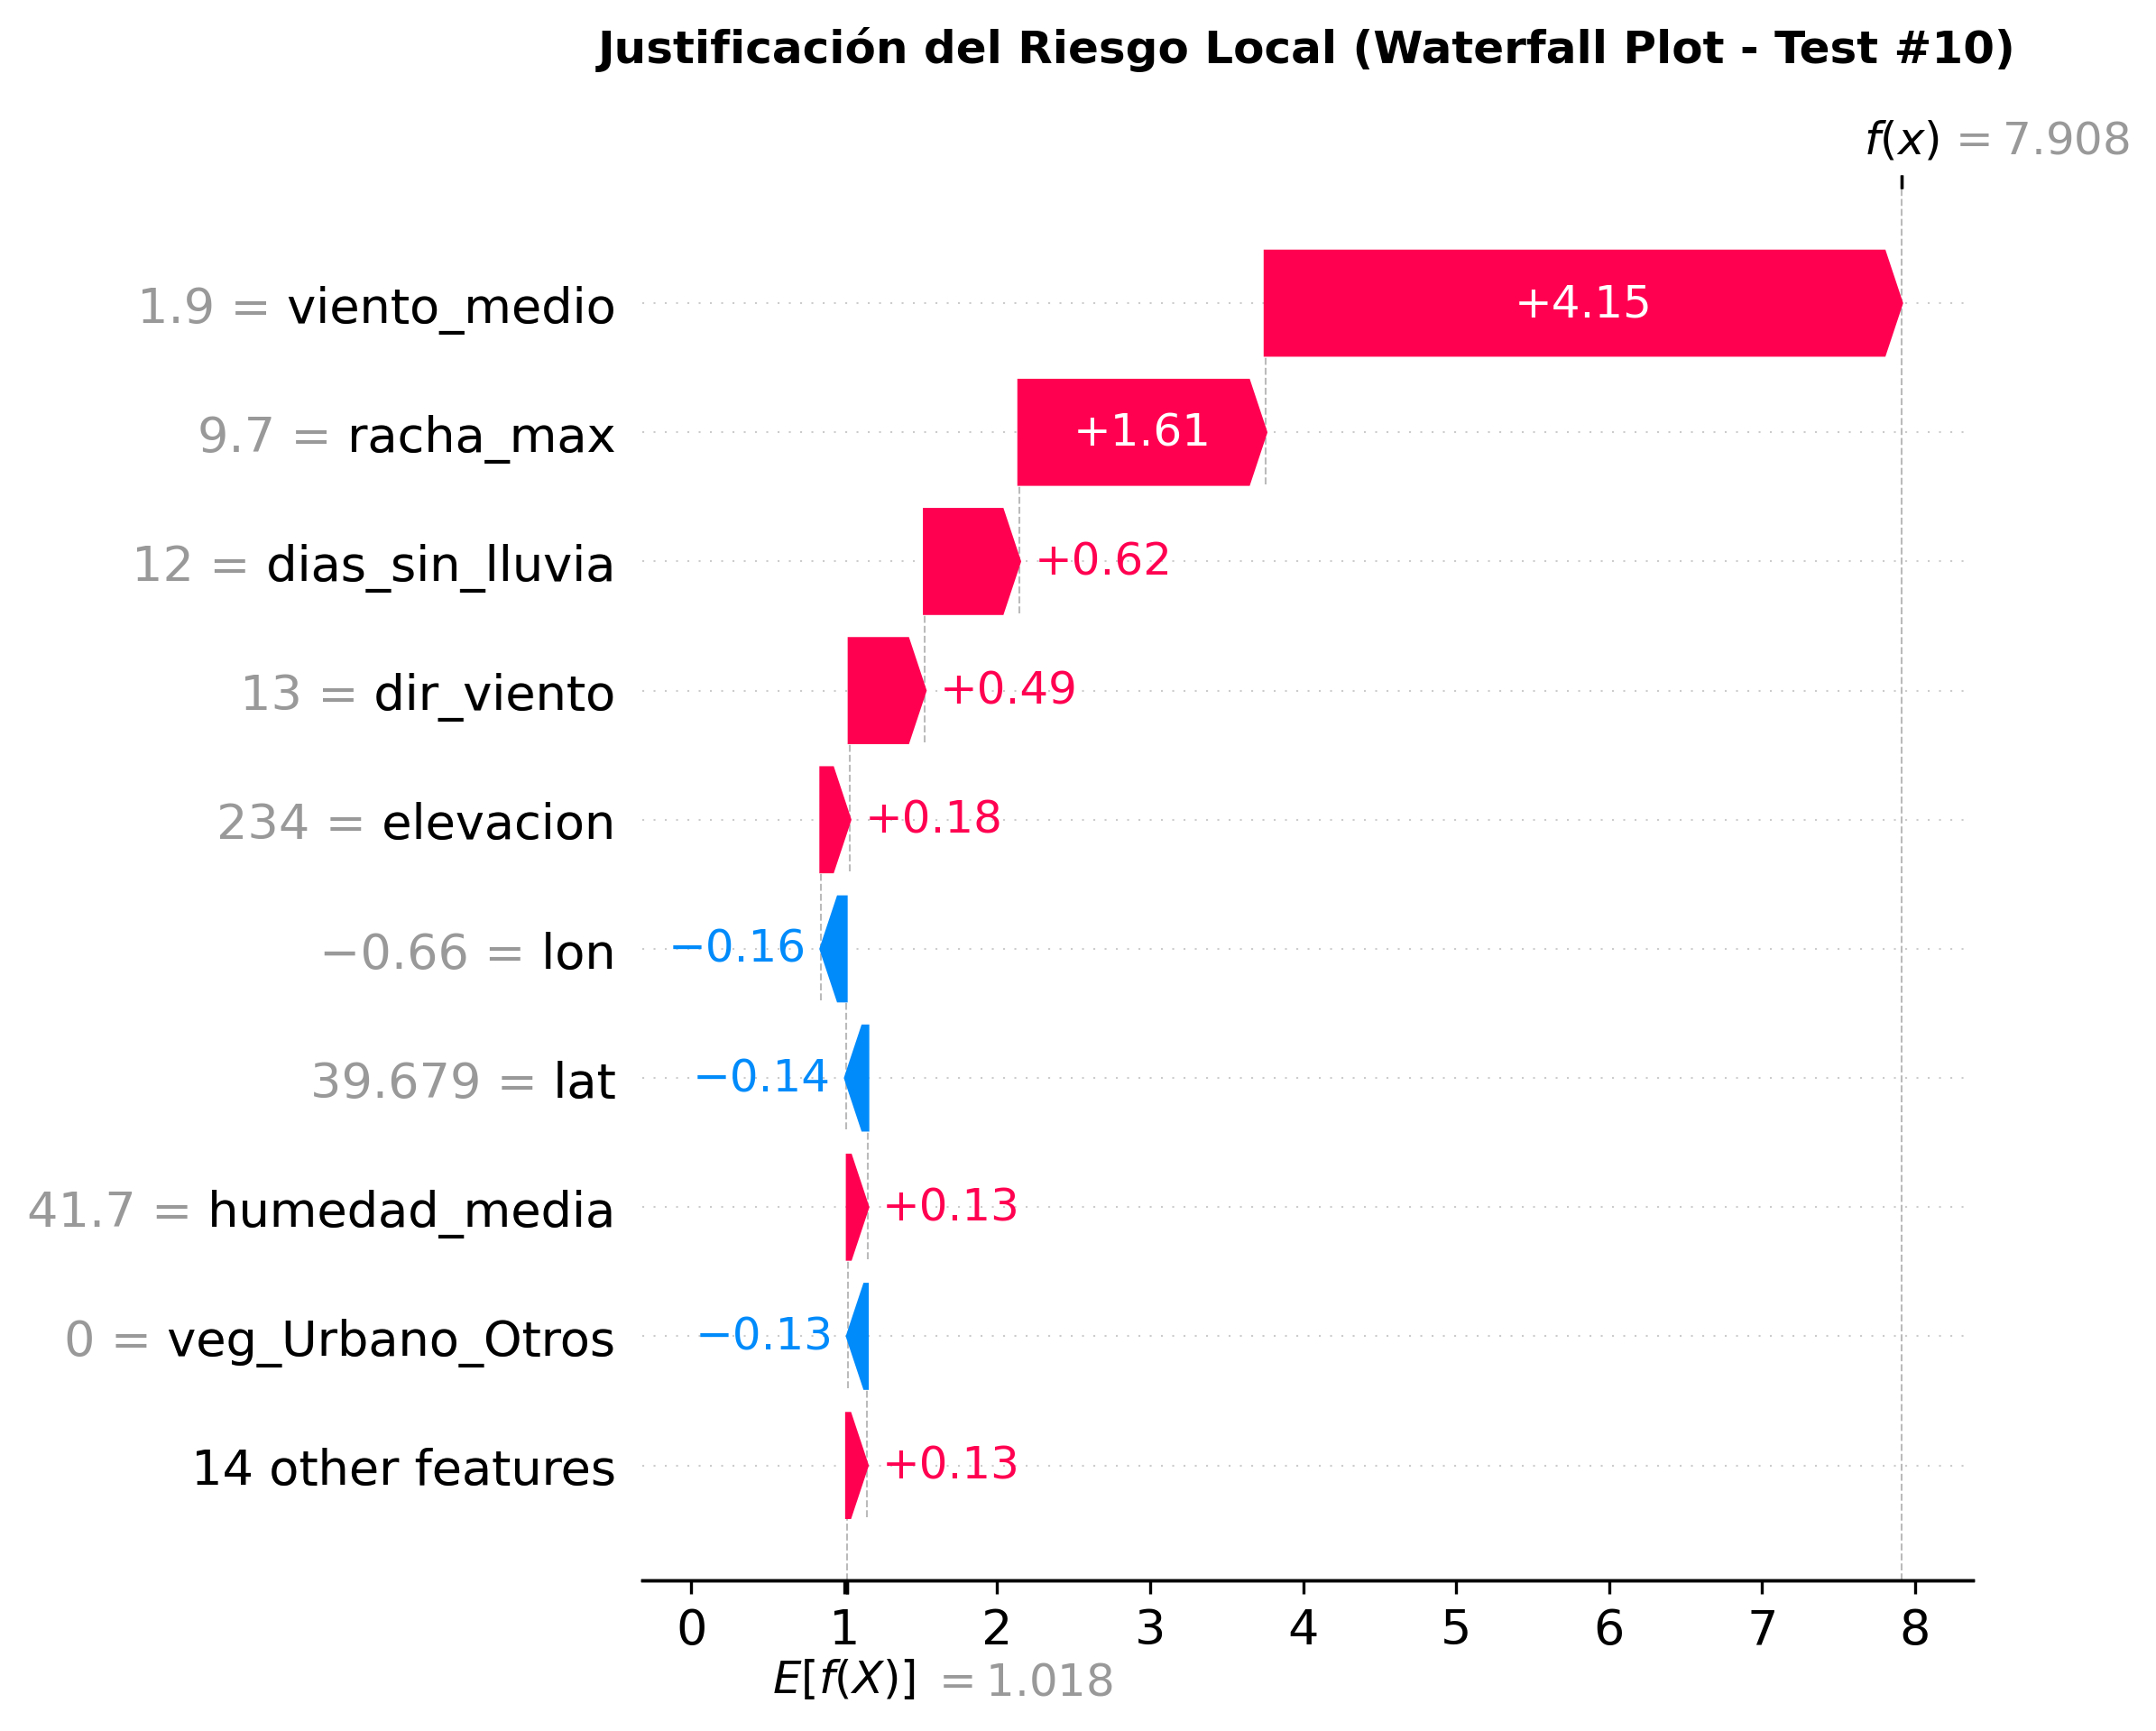

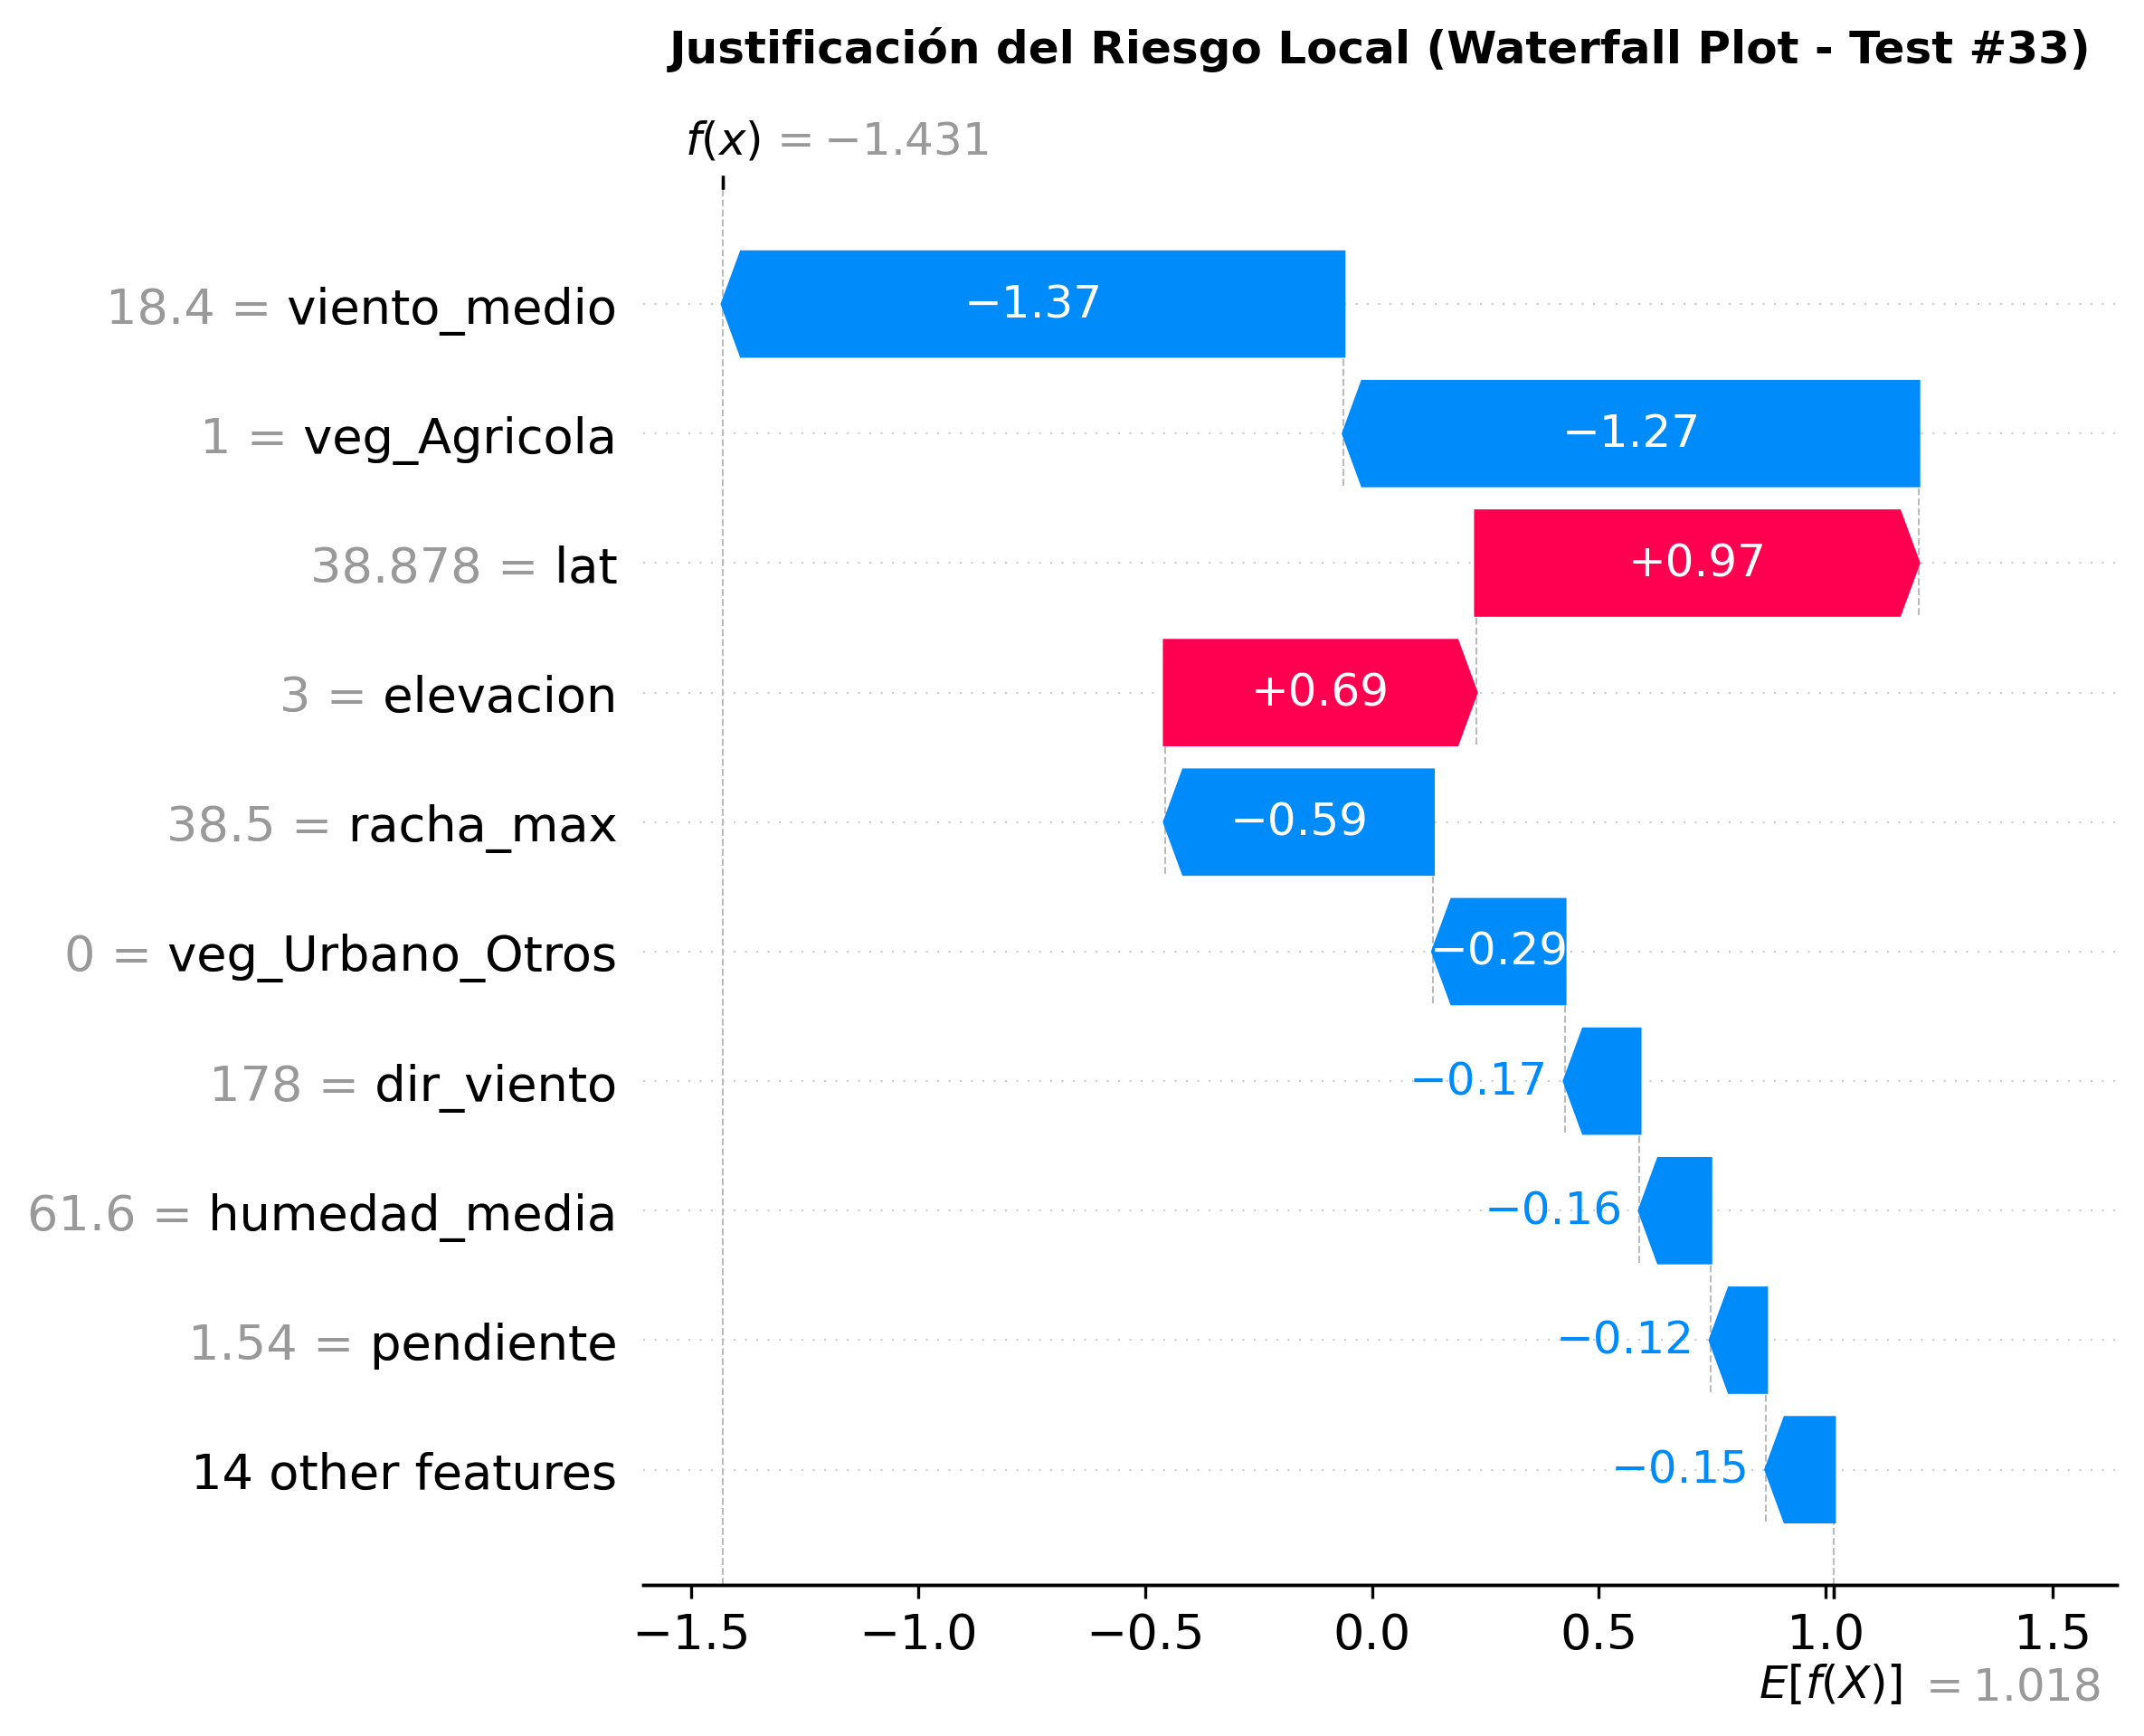

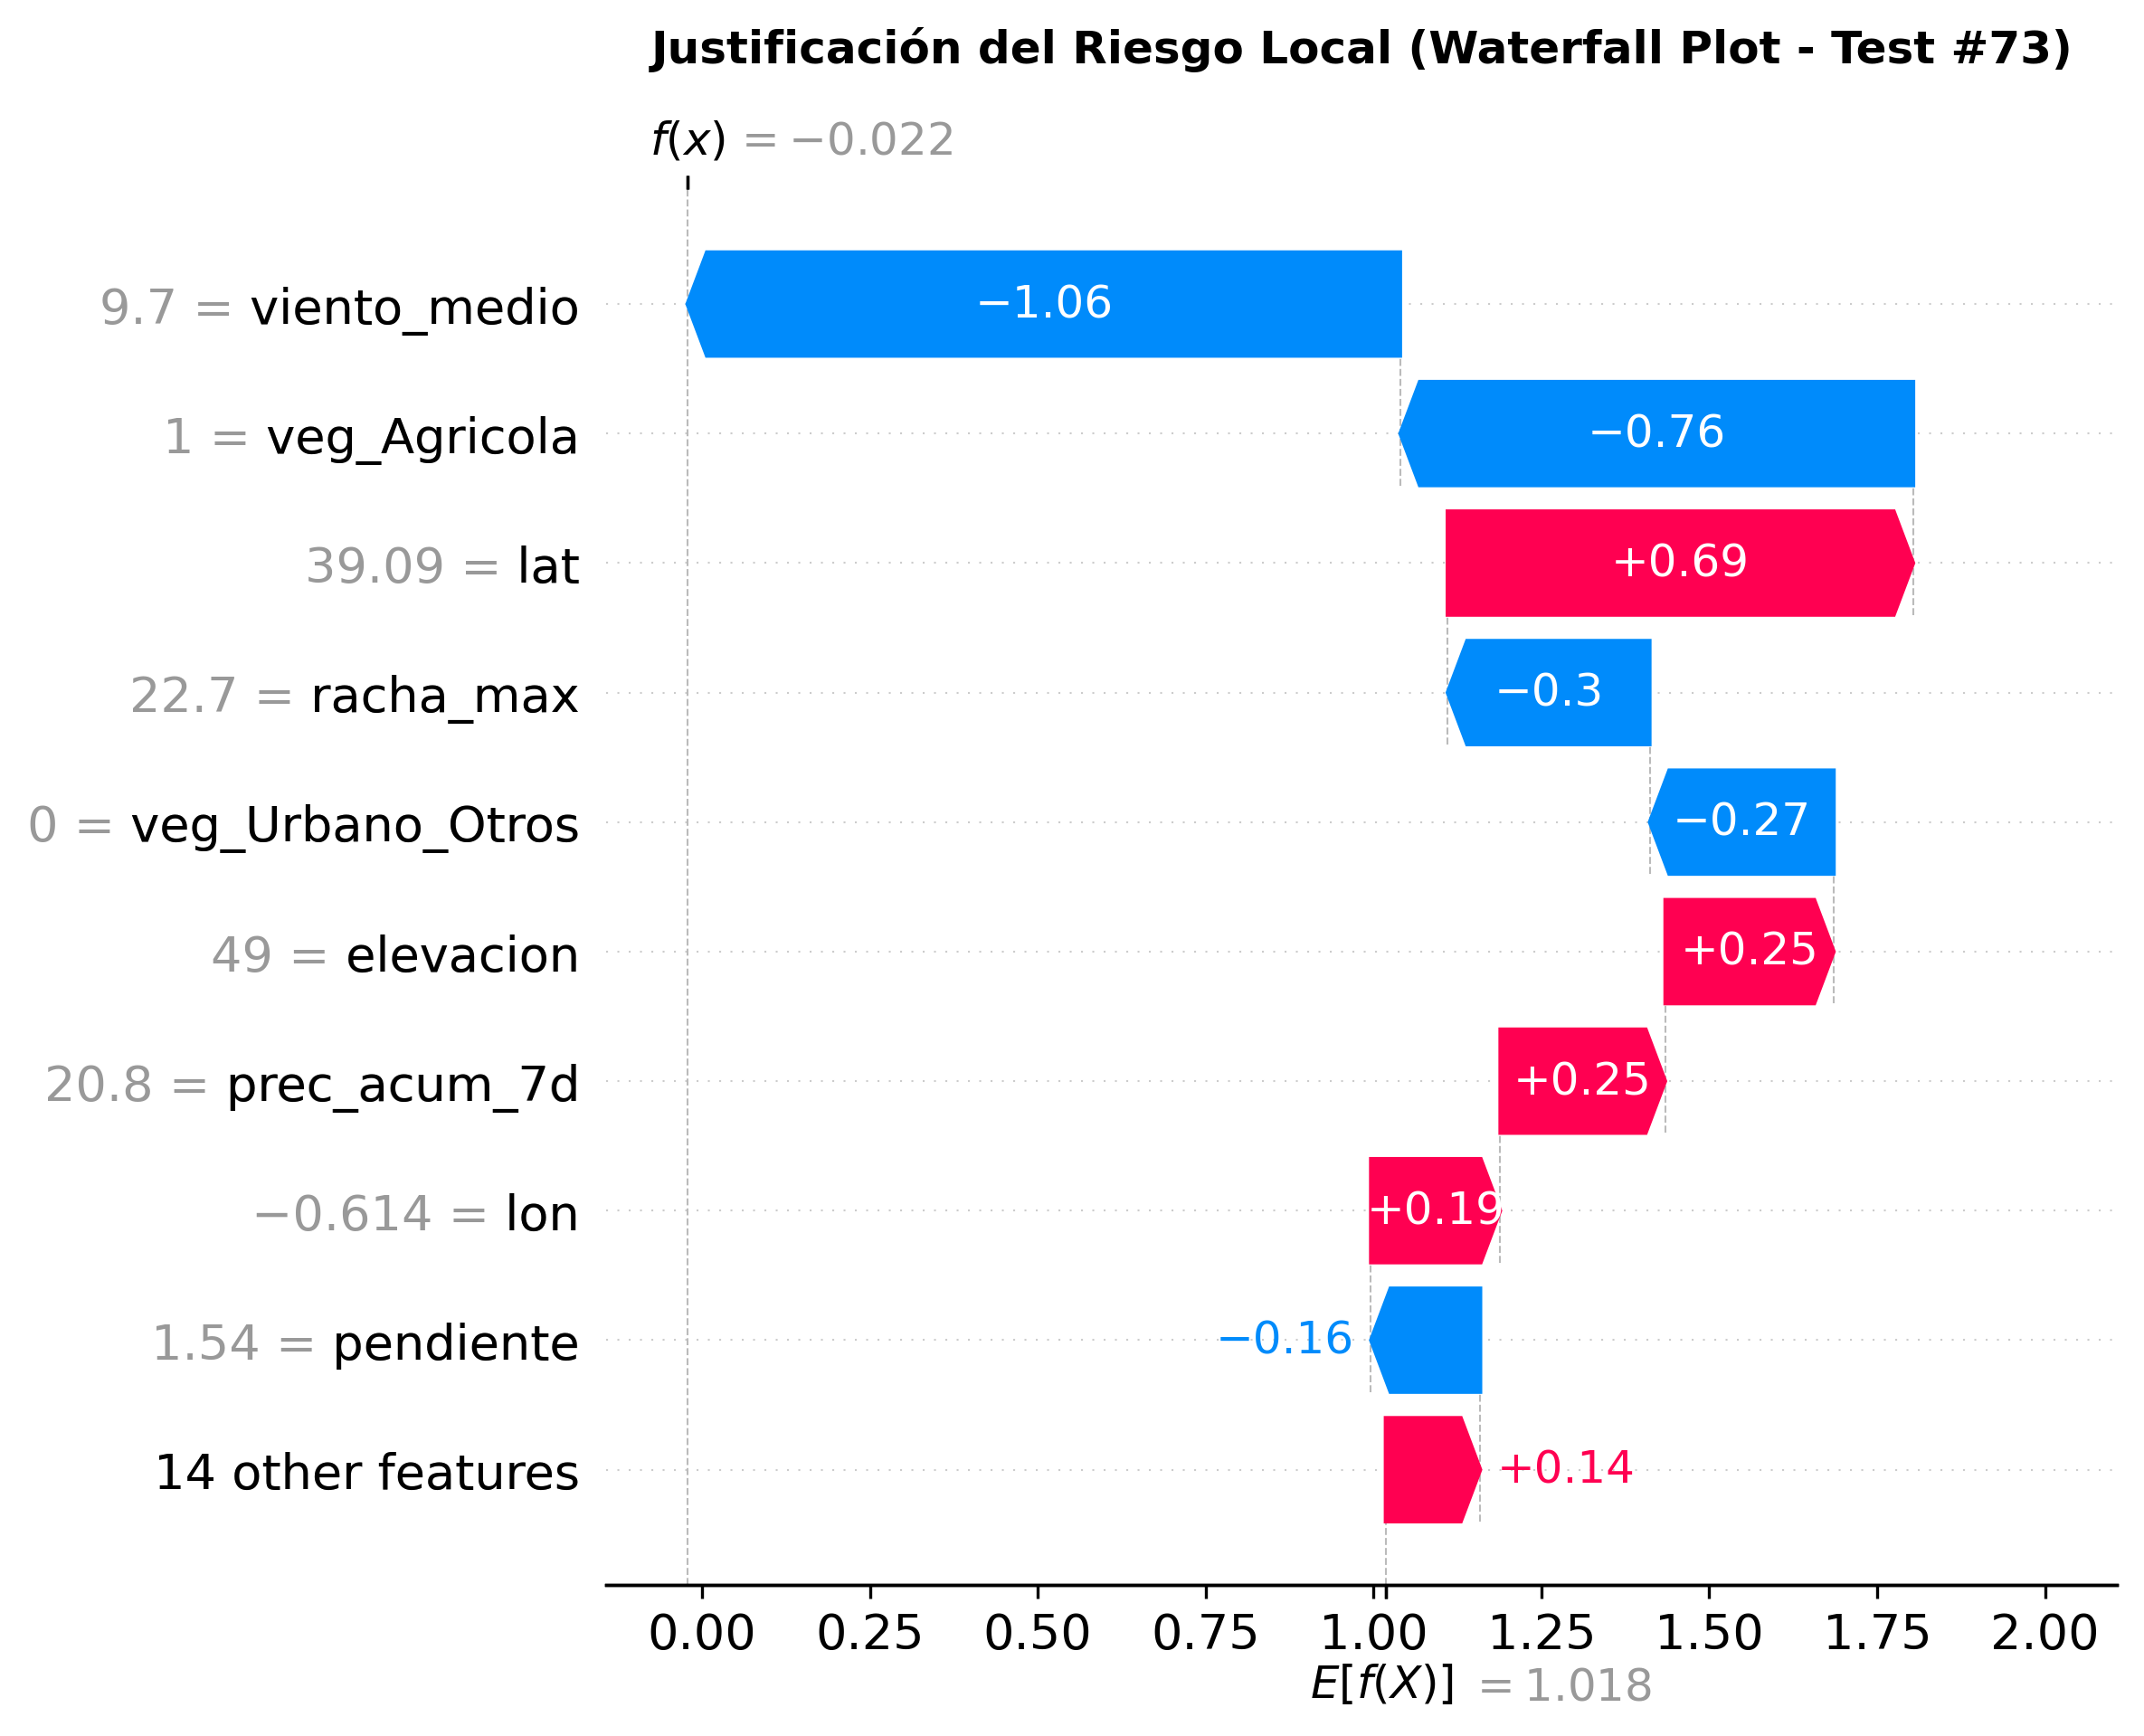

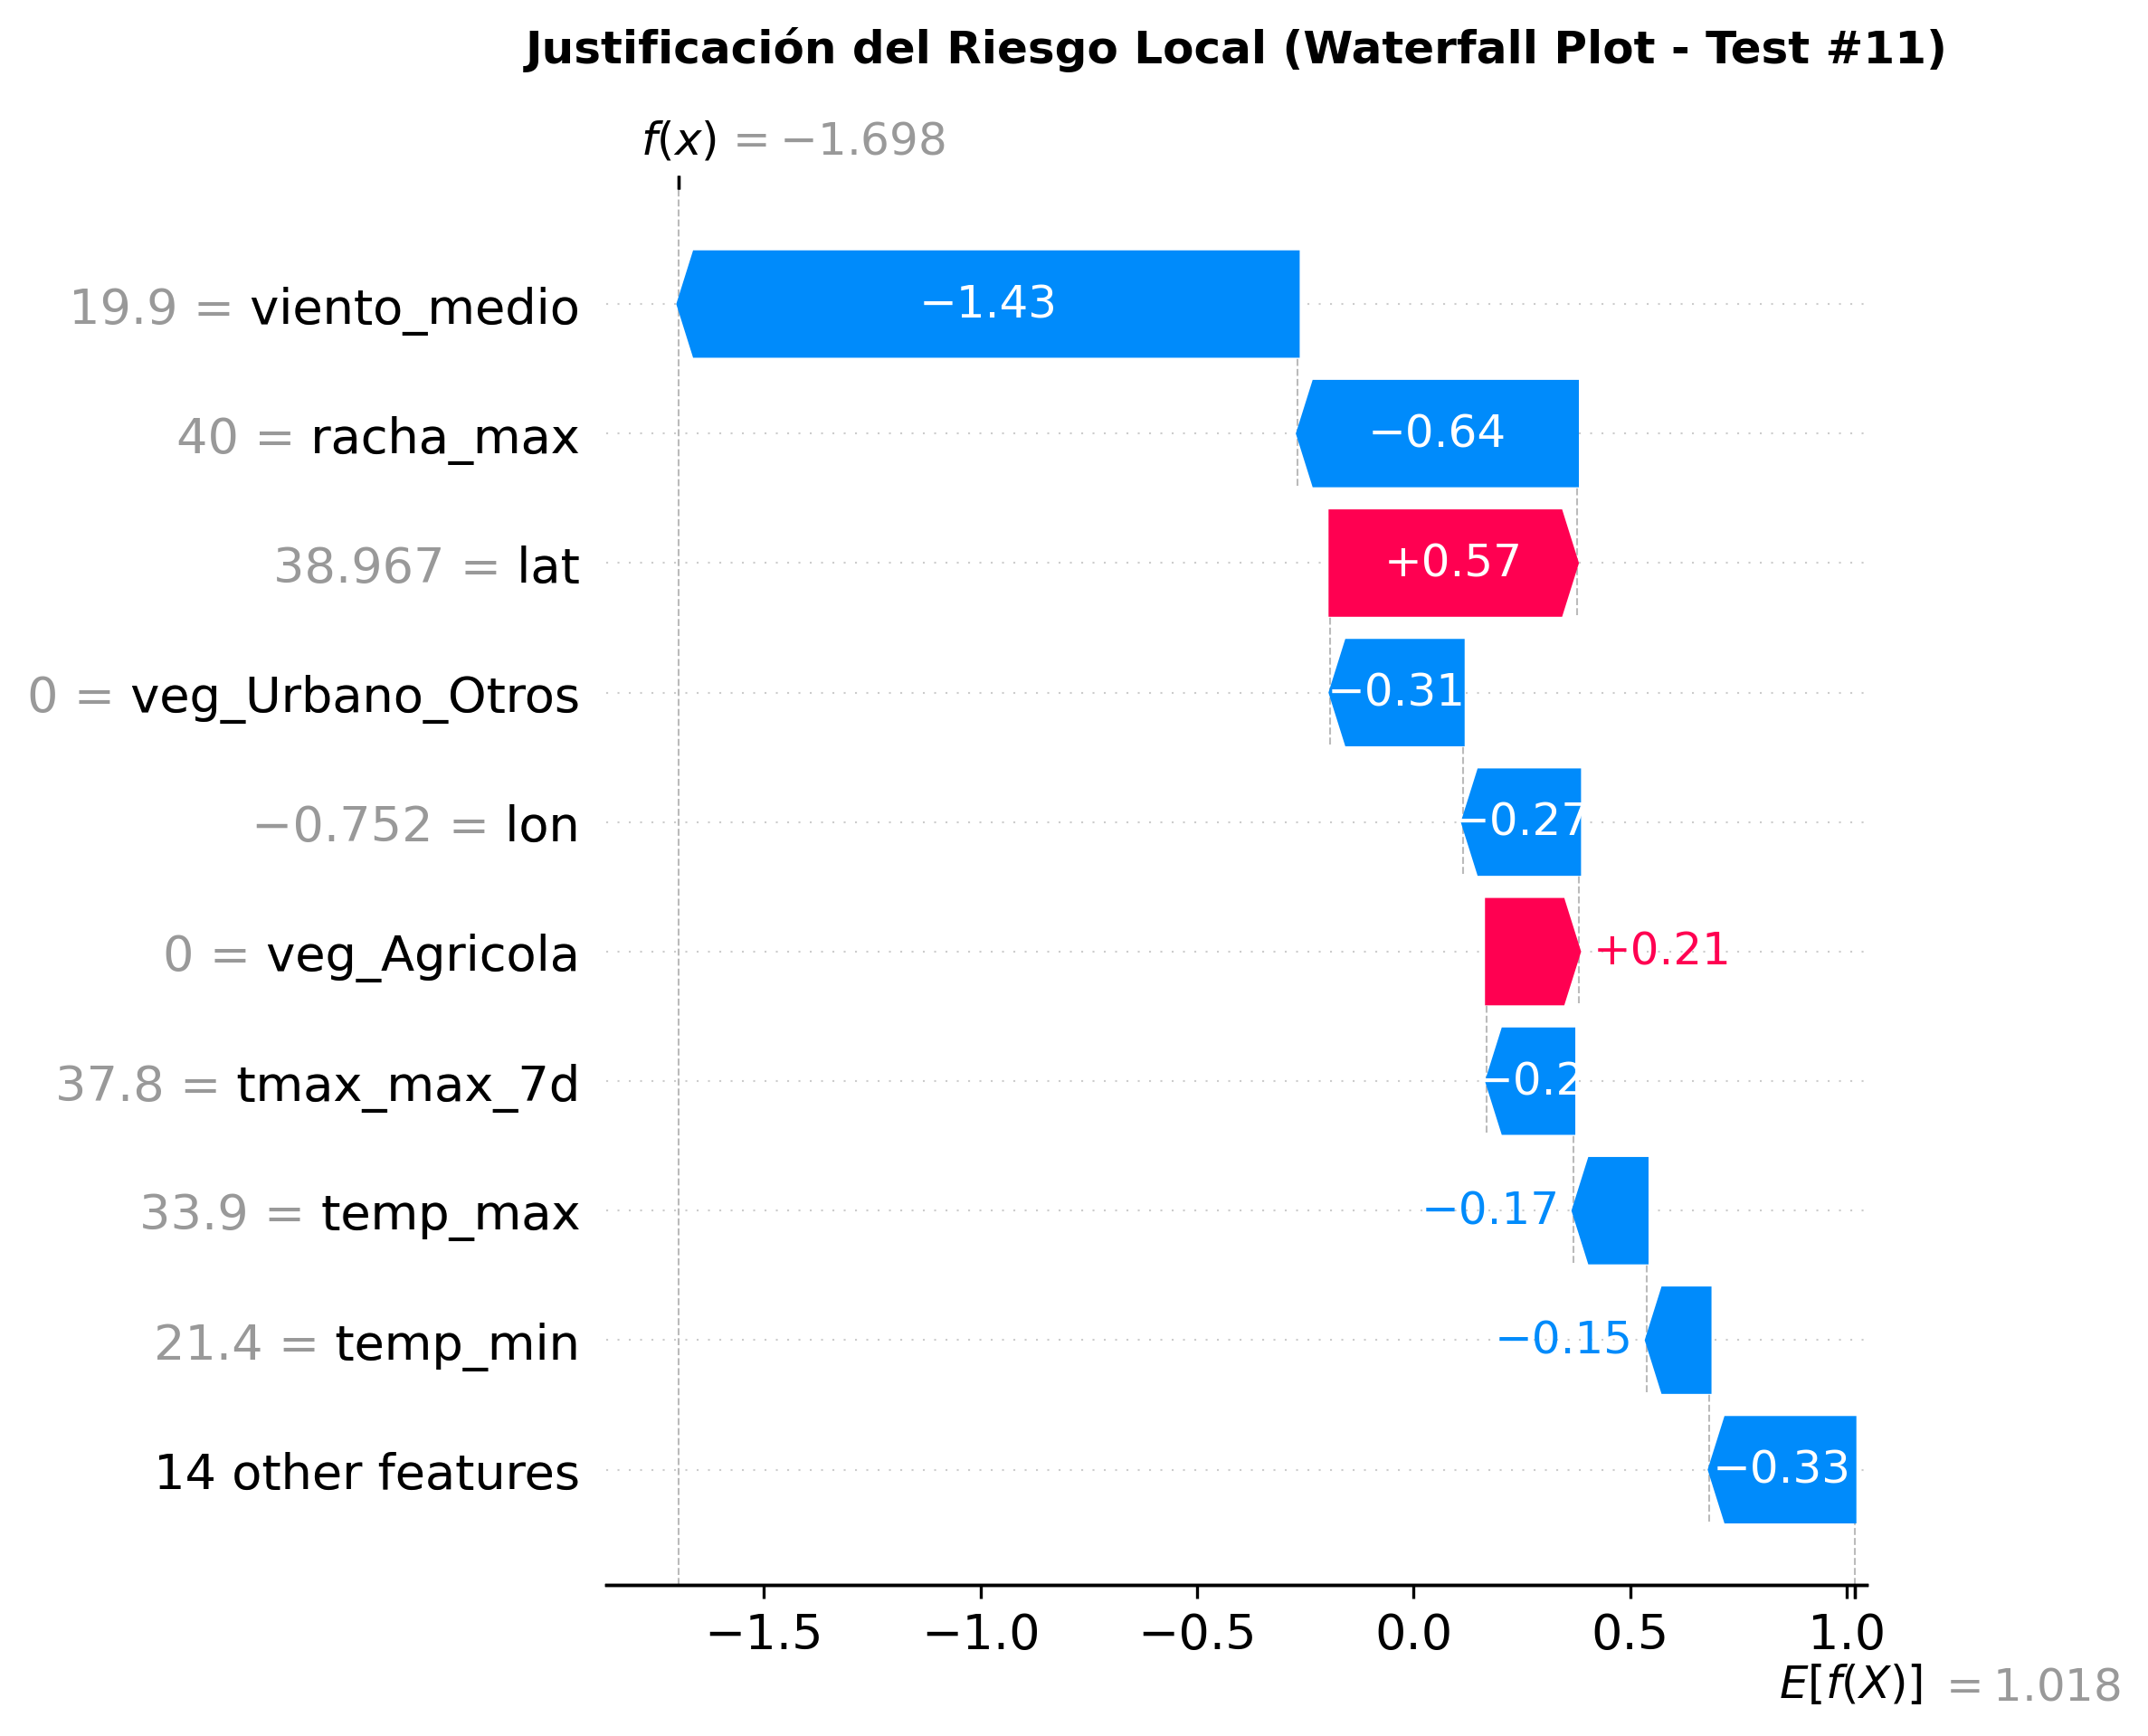

In [6]:
print("===========================================================")
print("PROBANDO CASOS EXISTENTES: TEST #10 Y TEST #33")
print("===========================================================")
print("Probando la función con el registro de Test #10...")
explicar_ignicion_local(10)

print("\nProbando la función con el registro de Test #33...")
explicar_ignicion_local(33)

print("\n===========================================================")
print("BUSCANDO CASO 3: EL ESCENARIO DE INCERTIDUMBRE / DUDA FRONTERIZA")
print("===========================================================")
indices_duda = np.where((y_proba >= 0.48) & (y_proba <= 0.52))[0]
if len(indices_duda) > 0:
    idx_duda = indices_duda[0]
    print(f"Encontrado registro de Test #{idx_duda} con probabilidad predictiva de {y_proba[idx_duda]*100:.2f}%")
    explicar_ignicion_local(idx_duda)
else:
    print("No se encontró ningún registro en la frontera 48%-52%")

print("\n===========================================================")
print("BUSCANDO CASO 4: EL FALSO NEGATIVO (FALLO DE OMISIÓN CRÍTICO)")
print("===========================================================")
indices_fn = np.where((y_test == 1) & (y_proba < 0.25))[0]
if len(indices_fn) > 0:
    idx_fn = indices_fn[0]
    print(f"Encontrado Falso Negativo en Test #{idx_fn} con probabilidad predictiva de {y_proba[idx_fn]*100:.2f}%")
    explicar_ignicion_local(idx_fn)
else:
    print("No se encontró ningún Falso Negativo con predicción < 25%")
